# Wikipedia pageviews (Lane A: you prompt, the agent builds)

**SISMID 2026 - Day 2, 9:00.** Drive **Codex / Claude Code / Antigravity CLI**. Each prompt
produces roughly the matching cell in the Lane B notebook. Not set up? Use Lane B.


## Step 0: point the agent at the task


i want to write a function that download Wikimedia pageviews, for example, dengue in english and in spanish and in chinese, Portuguese.



> *Using the public Wikimedia REST pageviews API (no key), write `wiki_fetch(article,*
> *wiki, start, end)` returning a tidy DataFrame (date, views), and a `load_cache()` that*
> *reads `data/wikipedia_dengue_pageviews_cached.csv`. Add `get_dengue_wiki()` that pulls*
> *English (Dengue_fever), Spanish (Dengue), Portuguese (Dengue), merges on date, and*
> *falls back to the cache on any failure. Set a descriptive User-Agent.*


In [1]:
# Paste the agent's helper functions here and run them.
import urllib.request, urllib.parse, json, os, time
import pandas as pd, matplotlib.pyplot as plt

USER_AGENT = "SISMID2026-course/1.0 (your-email@example.com)"  # put a real contact
CACHE_PATHS = ["../data/wikipedia_dengue_pageviews_cached.csv",
               "data/wikipedia_dengue_pageviews_cached.csv",
               "./wikipedia_dengue_pageviews_cached.csv"]


def wiki_fetch(article, wiki, start="2016010100", end=None, granularity="monthly"):
    """Wikipedia pageviews for one article. Returns DataFrame(date, views) or None.
    `granularity` is 'monthly' or 'daily'. `end` defaults to the current month/day,
    so pulls stay current without editing this default."""
    end = end or time.strftime("%Y%m0100" if granularity == "monthly" else "%Y%m%d00")
    safe_article = urllib.parse.quote(article, safe="")
    url = (f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/"
           f"{wiki}/all-access/all-agents/{safe_article}/{granularity}/{start}/{end}")
    try:
        req = urllib.request.Request(url, headers={"User-Agent": USER_AGENT})
        items = json.loads(urllib.request.urlopen(req, timeout=30).read())["items"]
        return pd.DataFrame([{"date": pd.to_datetime(it["timestamp"][:8], format="%Y%m%d"),
                              "views": it["views"]} for it in items])
    except Exception as e:
        print(f"Wikipedia live pull failed ({type(e).__name__}): {e}")
        return None


def load_cache():
    for p in CACHE_PATHS:
        if os.path.exists(p):
            print(f"Using cached snapshot: {p}")
            return pd.read_csv(p, parse_dates=["date"])
    raise FileNotFoundError("Wikipedia cache not found; check the data/ folder.")


def get_dengue_wiki(granularity="monthly", start="2016010100"):
    """English, Spanish, Chinese and Portuguese dengue pageviews, merged on date.
    Falls back to the cache (en/es/pt only, monthly) if any live pull fails."""
    en = wiki_fetch("Dengue_fever", "en.wikipedia", start=start, granularity=granularity)
    es = wiki_fetch("Dengue", "es.wikipedia", start=start, granularity=granularity)
    zh = wiki_fetch("骨痛熱症", "zh.wikipedia", start=start, granularity=granularity)   # zh.wikipedia's canonical title for dengue fever
    pt = wiki_fetch("Dengue", "pt.wikipedia", start=start, granularity=granularity)
    if en is None or es is None or zh is None or pt is None:
        if granularity != "monthly":
            raise RuntimeError("Live pull failed and the cache is monthly-only.")
        return load_cache()   # any failure -> the merged cached snapshot (en/es/pt)
    return (en.rename(columns={"views": "dengue_en"})
              .merge(es.rename(columns={"views": "dengue_es"}), on="date")
              .merge(zh.rename(columns={"views": "dengue_zh"}), on="date")
              .merge(pt.rename(columns={"views": "dengue_pt"}), on="date"))


## Step 1: pull three languages and overlay

> *Use get_dengue_wiki() to build the merged frame; print the row count and date range,*
> *and overlay the three language series on one plot.*

**Your check:** do the peaks line up with dengue seasons in those regions?


rows: 127 | range: 2016-01-01 to 2026-07-01


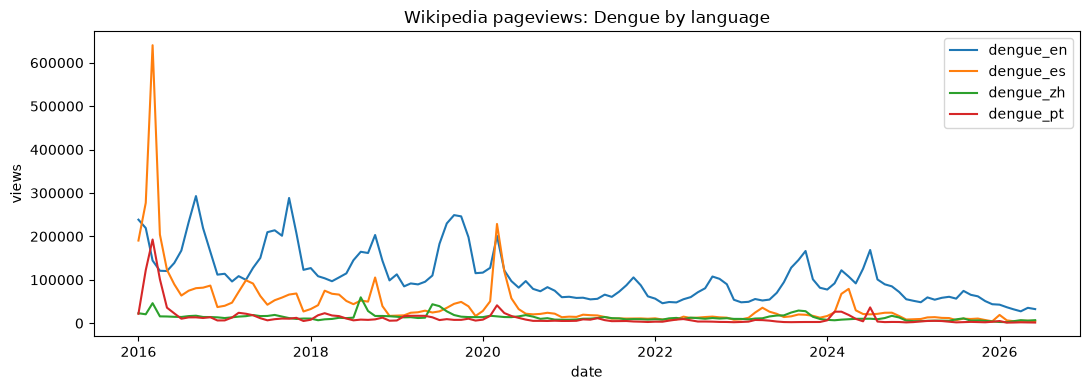

,date,dengue_en,dengue_es,dengue_zh,dengue_pt
122,2026-03-01,32043,4646,4567,1586
123,2026-04-01,27389,5343,6961,2047
124,2026-05-01,35417,5557,5887,1766
125,2026-06-01,32471,4953,6987,1530
126,2026-07-01,1142,165,471,42


In [2]:
# Agent's fetch + overlay:
df = get_dengue_wiki()
print("rows:", len(df), "| range:", df["date"].min().date(), "to", df["date"].max().date())

# drop the current (partial) month so it doesn't plot as a fake dip
current_month = pd.Timestamp(time.strftime("%Y-%m-01"))
plot_df = df[df["date"] < current_month]

cols = [c for c in df.columns if c != "date"]
plt.figure(figsize=(11, 4))
for c in cols:
    plt.plot(plot_df["date"], plot_df[c], label=c)
plt.legend()
plt.title("Wikipedia pageviews: Dengue by language")
plt.ylabel("views")
plt.xlabel("date")
plt.tight_layout()
plt.savefig("../dengue_wikipedia_pageviews.png", dpi=150)
plt.show()
df.tail()


rows: 365 | range: 2025-07-21 to 2026-07-20


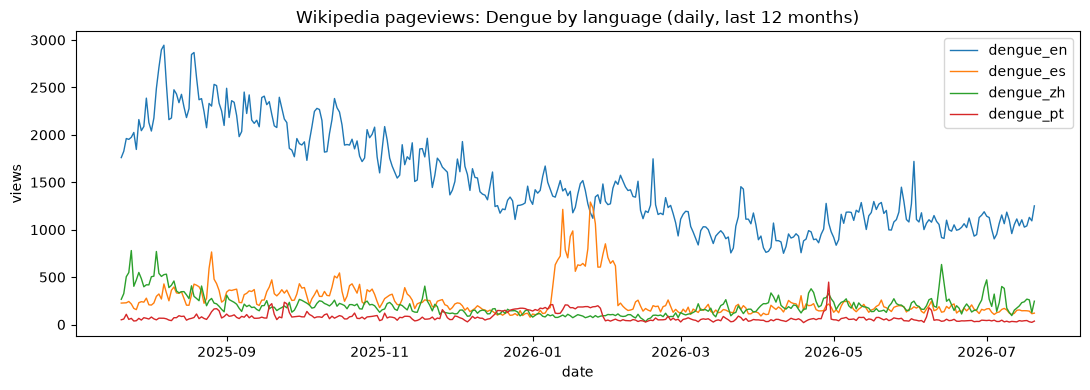

,date,dengue_en,dengue_es,dengue_zh,dengue_pt
360,2026-07-16,1027,146,240,40
361,2026-07-17,1040,145,268,42
362,2026-07-18,1130,141,260,29
363,2026-07-19,1093,114,126,23
364,2026-07-20,1251,120,246,36


In [3]:
# Daily granularity, last 12 months:
daily_start = (pd.Timestamp.today() - pd.DateOffset(years=1)).strftime("%Y%m%d00")
daily = get_dengue_wiki(granularity="daily", start=daily_start)
print("rows:", len(daily), "| range:", daily["date"].min().date(), "to", daily["date"].max().date())

cols = [c for c in daily.columns if c != "date"]
plt.figure(figsize=(11, 4))
for c in cols:
    plt.plot(daily["date"], daily[c], label=c, linewidth=1)
plt.legend()
plt.title("Wikipedia pageviews: Dengue by language (daily, last 12 months)")
plt.ylabel("views")
plt.xlabel("date")
plt.tight_layout()
plt.savefig("../dengue_wikipedia_pageviews_daily.png", dpi=150)
plt.show()
daily.tail()


## Step 2: reproducibility

> *Pull the English series twice and report whether the two pulls are identical.*

They should be - the contrast with Google Trends' sampling noise.


In [4]:
# Agent's reproducibility check:


## Step 3: sanity-check and save

> *Report missing values per column and the correlation between the language series,*
> *then save the merged frame to `dengue_wikipedia.csv` and confirm.*


In [5]:
# Agent's sanity-check + save:


## Reflection

- You described outcomes and checks; the agent wrote the API plumbing.
- Wikipedia is the well-behaved stream; the same loop you used on Google Trends works.
- **Stretch:** swap in your own disease/article and languages.
